 🎬  CineIndia — Movie Recommendation System

Install Dependencies

In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "pandas", "scikit-learn", "flask", "flask-cors"], check=True)

import pandas as pd
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

Build Dataset (All Indian Languages)

In [2]:
DATA = [
    # Hindi
    {"title":"3 Idiots","language":"Hindi","year":2009,"genre":"Comedy,Drama","director":"Rajkumar Hirani","cast":"Aamir Khan, Madhavan, Sharman Joshi","rating":8.4,"votes":380000,"description":"Two friends search for their long-lost companion while reminiscing about their college days and the lessons their rebellious friend taught them."},
    {"title":"Dangal","language":"Hindi","year":2016,"genre":"Biography,Drama,Sport","director":"Nitesh Tiwari","cast":"Aamir Khan, Fatima Sana Shaikh, Sanya Malhotra","rating":8.3,"votes":270000,"description":"Former wrestler Mahavir Singh Phogat trains his daughters to become world-class wrestlers against all odds."},
    {"title":"Lagaan","language":"Hindi","year":2001,"genre":"Adventure,Drama,Sport","director":"Ashutosh Gowariker","cast":"Aamir Khan, Gracy Singh, Rachel Shelley","rating":8.1,"votes":120000,"description":"Villagers in 19th century India accept a challenge to play cricket against British officers to avoid paying heavy taxes."},
    {"title":"Dil Chahta Hai","language":"Hindi","year":2001,"genre":"Comedy,Drama,Romance","director":"Farhan Akhtar","cast":"Aamir Khan, Saif Ali Khan, Akshaye Khanna","rating":8.1,"votes":110000,"description":"Three inseparable friends navigate life, love, and friendship after college graduation."},
    {"title":"Swades","language":"Hindi","year":2004,"genre":"Drama","director":"Ashutosh Gowariker","cast":"Shah Rukh Khan, Gayatri Joshi","rating":8.0,"votes":90000,"description":"A successful NASA scientist returns to India to bring his childhood nanny to the US, but reconnects with his roots."},
    {"title":"Taare Zameen Par","language":"Hindi","year":2007,"genre":"Drama,Family","director":"Aamir Khan","cast":"Darsheel Safary, Aamir Khan","rating":8.4,"votes":160000,"description":"An eight-year-old boy is thought to be a lazy trouble-maker until a teacher recognizes that he has dyslexia."},
    {"title":"Queen","language":"Hindi","year":2014,"genre":"Adventure,Comedy,Drama","director":"Vikas Bahl","cast":"Kangana Ranaut, Rajkummar Rao","rating":8.1,"votes":130000,"description":"A Delhi girl goes on her honeymoon alone after her fiancé calls off their wedding, discovering herself in Paris and Amsterdam."},
    {"title":"Andhadhun","language":"Hindi","year":2018,"genre":"Comedy,Crime,Thriller","director":"Sriram Raghavan","cast":"Ayushmann Khurrana, Tabu, Radhika Apte","rating":8.3,"votes":210000,"description":"A series of events involving a blind pianist, an actress, and a police officer take a deadly turn."},
    {"title":"Gully Boy","language":"Hindi","year":2019,"genre":"Drama,Music","director":"Zoya Akhtar","cast":"Ranveer Singh, Alia Bhatt","rating":7.9,"votes":115000,"description":"A street rapper from Mumbai's slums rises to fame inspired by the underground rap movement."},
    {"title":"Drishyam","language":"Hindi","year":2015,"genre":"Crime,Drama,Thriller","director":"Nishikant Kamat","cast":"Ajay Devgn, Tabu, Shriya Saran","rating":8.2,"votes":185000,"description":"A man goes to great lengths to protect his family from the police investigation of an accidental killing."},
    {"title":"PK","language":"Hindi","year":2014,"genre":"Comedy,Drama,Fantasy","director":"Rajkumar Hirani","cast":"Aamir Khan, Anushka Sharma","rating":8.1,"votes":240000,"description":"An alien on a research mission to Earth is accidentally stranded and needs human help to find his remote control."},
    {"title":"Kabhi Khushi Kabhie Gham","language":"Hindi","year":2001,"genre":"Drama,Family,Musical","director":"Karan Johar","cast":"Amitabh Bachchan, Shah Rukh Khan, Kajol","rating":7.4,"votes":105000,"description":"A wealthy patriarch's adopted son searches for his biological roots while trying to reunite his divided family."},
    {"title":"Rang De Basanti","language":"Hindi","year":2006,"genre":"Drama","director":"Rakeysh Omprakash Mehra","cast":"Aamir Khan, Siddharth, R. Madhavan","rating":8.1,"votes":145000,"description":"A group of carefree college students transform after portraying Indian revolutionaries in a documentary film."},
    {"title":"Mughal-E-Azam","language":"Hindi","year":1960,"genre":"Drama,History,Romance","director":"K. Asif","cast":"Dilip Kumar, Madhubala, Prithviraj Kapoor","rating":8.2,"votes":35000,"description":"The Mughal emperor Akbar objects to Prince Salim's love for court dancer Anarkali, leading to epic conflict."},
    {"title":"Sholay","language":"Hindi","year":1975,"genre":"Action,Adventure,Drama","director":"Ramesh Sippy","cast":"Amitabh Bachchan, Dharmendra, Sanjeev Kumar","rating":8.2,"votes":72000,"description":"Two criminals are hired by a retired police officer to capture a notorious bandit who terrorizes his village."},
    {"title":"Bajrangi Bhaijaan","language":"Hindi","year":2015,"genre":"Adventure,Drama","director":"Kabir Khan","cast":"Salman Khan, Harshaali Malhotra","rating":8.1,"votes":195000,"description":"A devotee of Hanuman helps a mute Pakistani girl lost in India return to her homeland against all odds."},
    {"title":"Article 15","language":"Hindi","year":2019,"genre":"Crime,Drama","director":"Anubhav Sinha","cast":"Ayushmann Khurrana, Nassar","rating":8.1,"votes":90000,"description":"An IPS officer investigates the missing cases of young Dalit girls in rural India uncovering deep-rooted caste discrimination."},
    {"title":"Masaan","language":"Hindi","year":2015,"genre":"Drama,Romance","director":"Neeraj Ghaywan","cast":"Richa Chadha, Vicky Kaushal","rating":8.2,"votes":80000,"description":"Two separate stories of loss and love unfold alongside the Ganges river in Varanasi."},
    {"title":"Gangs of Wasseypur","language":"Hindi","year":2012,"genre":"Action,Crime,Drama","director":"Anurag Kashyap","cast":"Manoj Bajpayee, Nawazuddin Siddiqui","rating":8.2,"votes":130000,"description":"A coal mafia saga spanning three generations of gangsters in Jharkhand's Wasseypur."},
    {"title":"Zindagi Na Milegi Dobara","language":"Hindi","year":2011,"genre":"Adventure,Comedy,Drama","director":"Zoya Akhtar","cast":"Hrithik Roshan, Farhan Akhtar, Abhay Deol","rating":8.1,"votes":150000,"description":"Three friends go on a road trip across Spain, confronting their fears and past baggage."},
    # Tamil
    {"title":"Vikram Vedha","language":"Tamil","year":2017,"genre":"Action,Crime,Thriller","director":"Pushkar-Gayathri","cast":"R. Madhavan, Vijay Sethupathi","rating":8.4,"votes":105000,"description":"A tough police officer sets out to track down and kill an equally tough gangster."},
    {"title":"Mersal","language":"Tamil","year":2017,"genre":"Action,Drama","director":"Atlee","cast":"Vijay, S. J. Suryah, Nithya Menen","rating":7.6,"votes":78000,"description":"A magician takes on a corrupt doctor in a battle of wits that spans generations."},
    {"title":"96","language":"Tamil","year":2018,"genre":"Drama,Romance","director":"C. Prem Kumar","cast":"Vijay Sethupathi, Trisha Krishnan","rating":8.5,"votes":72000,"description":"Two former classmates reunite after 22 years and reminisce about their childhood love."},
    {"title":"Pariyerum Perumal","language":"Tamil","year":2018,"genre":"Drama","director":"Mari Selvaraj","cast":"Kathir, Anandhi","rating":8.5,"votes":52000,"description":"A Dalit student faces caste discrimination in law college but finds a mentor who guides him through prejudice."},
    {"title":"Soorarai Pottru","language":"Tamil","year":2020,"genre":"Biography,Drama","director":"Sudha Kongara","cast":"Suriya, Aparna Balamurali","rating":8.7,"votes":110000,"description":"The inspiring journey of a man from a small town who builds a low-cost airline challenging the aviation industry."},
    {"title":"Karnan","language":"Tamil","year":2021,"genre":"Action,Drama","director":"Mari Selvaraj","cast":"Dhanush, Rajisha Vijayan","rating":8.3,"votes":65000,"description":"A fierce young man in a marginalized village fights for the rights and dignity of his community."},
    {"title":"Master","language":"Tamil","year":2021,"genre":"Action,Drama","director":"Lokesh Kanagaraj","cast":"Vijay, Vijay Sethupathi","rating":7.8,"votes":92000,"description":"A college professor with a drinking problem battles a ruthless gangster who uses juvenile inmates for crime."},
    {"title":"Jai Bhim","language":"Tamil","year":2021,"genre":"Drama,Thriller","director":"T.J. Gnanavel","cast":"Suriya, Manikandan","rating":8.8,"votes":195000,"description":"A high court lawyer fights for justice for a tribal woman whose husband was illegally detained and killed by police."},
    {"title":"Ponniyin Selvan I","language":"Tamil","year":2022,"genre":"Action,Adventure,Drama","director":"Mani Ratnam","cast":"Vikram, Aishwarya Rai","rating":7.6,"votes":88000,"description":"The epic story of the Chola dynasty set in 10th century Tamil Nadu, filled with political intrigue and war."},
    {"title":"Kaithi","language":"Tamil","year":2019,"genre":"Action,Thriller","director":"Lokesh Kanagaraj","cast":"Karthi, Narain","rating":8.5,"votes":88000,"description":"An ex-convict gets entangled in a drug bust on the night he is finally reunited with his daughter."},
    # Telugu
    {"title":"RRR","language":"Telugu","year":2022,"genre":"Action,Adventure,Drama","director":"S.S. Rajamouli","cast":"N.T. Rama Rao Jr., Ram Charan","rating":8.0,"votes":310000,"description":"A fictional story about two legendary Indian freedom fighters before they took up arms against British rule."},
    {"title":"Baahubali: The Beginning","language":"Telugu","year":2015,"genre":"Action,Adventure,Drama","director":"S.S. Rajamouli","cast":"Prabhas, Rana Daggubati","rating":8.0,"votes":350000,"description":"In ancient India, an adventurous and powerful prince sets out to discover his true heritage and his destiny."},
    {"title":"Baahubali 2: The Conclusion","language":"Telugu","year":2017,"genre":"Action,Adventure,Drama","director":"S.S. Rajamouli","cast":"Prabhas, Anushka Shetty","rating":8.2,"votes":400000,"description":"When Shiva, the son of Bahubali, learns about his heritage, he begins to question why Kattappa killed his father."},
    {"title":"Arjun Reddy","language":"Telugu","year":2017,"genre":"Drama,Romance","director":"Sandeep Reddy Vanga","cast":"Vijay Deverakonda, Shalini Pandey","rating":8.1,"votes":125000,"description":"A short-tempered house surgeon gets used to drugs and alcohol after his girlfriend is forced to marry someone else."},
    {"title":"Mahanati","language":"Telugu","year":2018,"genre":"Biography,Drama","director":"Nag Ashwin","cast":"Keerthy Suresh, Dulquer Salmaan","rating":8.4,"votes":68000,"description":"The life story of legendary Telugu actress Savitri, who became one of the most celebrated stars of Indian cinema."},
    {"title":"Jersey","language":"Telugu","year":2019,"genre":"Drama,Sport","director":"Gowtam Tinnanuri","cast":"Nani, Shraddha Srinath","rating":8.6,"votes":72000,"description":"A failed cricketer decides to return to cricket in his late thirties to fulfil his son's wish of having a jersey."},
    {"title":"Pushpa: The Rise","language":"Telugu","year":2021,"genre":"Action,Crime,Drama","director":"Sukumar","cast":"Allu Arjun, Rashmika Mandanna","rating":7.6,"votes":165000,"description":"A laborer rises in the red sandalwood smuggling syndicate while battling ruthless enemies and a corrupt police force."},
    # Malayalam
    {"title":"Drishyam","language":"Malayalam","year":2013,"genre":"Crime,Drama,Thriller","director":"Jeethu Joseph","cast":"Mohanlal, Meena","rating":8.3,"votes":95000,"description":"A man with no formal education uses his love of films and quick thinking to protect his family from a police investigation."},
    {"title":"Premam","language":"Malayalam","year":2015,"genre":"Drama,Romance","director":"Alphonse Puthren","cast":"Nivin Pauly, Madonna Sebastian","rating":8.3,"votes":85000,"description":"Three different phases of a young man's love life across his school, college, and adult years."},
    {"title":"Kumbalangi Nights","language":"Malayalam","year":2019,"genre":"Drama,Romance","director":"Madhu C. Narayanan","cast":"Shane Nigam, Fahadh Faasil","rating":8.5,"votes":62000,"description":"Four brothers in a dysfunctional family slowly rebuild their bonds while their neighbor's household hides dark secrets."},
    {"title":"Lucifer","language":"Malayalam","year":2019,"genre":"Action,Crime,Drama","director":"Prithviraj Sukumaran","cast":"Mohanlal, Vivek Oberoi","rating":7.8,"votes":98000,"description":"The death of Kerala's beloved Chief Minister sets off a political storm, with a mysterious figure emerging from the shadows."},
    {"title":"Jallikattu","language":"Malayalam","year":2019,"genre":"Action,Thriller","director":"Lijo Jose Pellissery","cast":"Antony Varghese, Chemban Vinod Jose","rating":7.5,"votes":35000,"description":"A buffalo escapes a slaughterhouse and runs amok in a small village, bringing out the primal instincts of its residents."},
    {"title":"Angamaly Diaries","language":"Malayalam","year":2017,"genre":"Action,Crime,Drama","director":"Lijo Jose Pellissery","cast":"Antony Varghese","rating":8.3,"votes":42000,"description":"A young man from a small town slowly gets drawn into the world of crime and violence."},
    {"title":"Super Deluxe","language":"Tamil","year":2019,"genre":"Drama,Thriller","director":"Thiagarajan Kumararaja","cast":"Vijay Sethupathi, Fahadh Faasil","rating":8.3,"votes":72000,"description":"Four different stories intertwine in unexpected ways in this dark anthology of morality and consequences."},
    {"title":"Minnal Murali","language":"Malayalam","year":2021,"genre":"Action,Comedy,Drama","director":"Basil Paulose","cast":"Tovino Thomas, Guru Somasundaram","rating":7.8,"votes":72000,"description":"A small-town tailor gains superpowers after being struck by lightning, as does a troubled villager with sinister motives."},
    # Kannada
    {"title":"KGF: Chapter 1","language":"Kannada","year":2018,"genre":"Action,Crime,Drama","director":"Prashanth Neel","cast":"Yash, Ramya Krishnan","rating":8.2,"votes":225000,"description":"A gangster rises from Mumbai's slums to become the most feared man in the Kolar Gold Fields."},
    {"title":"KGF: Chapter 2","language":"Kannada","year":2022,"genre":"Action,Crime,Drama","director":"Prashanth Neel","cast":"Yash, Sanjay Dutt","rating":8.4,"votes":305000,"description":"Rocky's bloodthirsty rage expands as his enemies grow, including threats from the government, Adheera, and Ramika Sen."},
    {"title":"Ulidavaru Kandanthe","language":"Kannada","year":2014,"genre":"Crime,Drama,Mystery","director":"Rakshit Shetty","cast":"Rakshit Shetty, Kishore","rating":8.6,"votes":28000,"description":"A story told from five different perspectives about a crime that occurred in a coastal Karnataka fishing village."},
    # Bengali
    {"title":"Pather Panchali","language":"Bengali","year":1955,"genre":"Drama","director":"Satyajit Ray","cast":"Kanu Bannerjee, Karuna Bannerjee, Uma Das Gupta","rating":8.3,"votes":48000,"description":"A poverty-stricken family in rural Bengal is seen through the eyes of young Apu, who dreams of a better life."},
    {"title":"Charulata","language":"Bengali","year":1964,"genre":"Drama,Romance","director":"Satyajit Ray","cast":"Soumitra Chatterjee, Madhabi Mukherjee","rating":8.3,"votes":22000,"description":"In 19th-century Bengal, a neglected wife develops a romantic bond with her husband's cousin, a writer like herself."},
    {"title":"Aparajito","language":"Bengali","year":1956,"genre":"Drama","director":"Satyajit Ray","cast":"Pinaki Sengupta, Smaran Ghosal","rating":8.1,"votes":22000,"description":"The second part of the Apu trilogy follows young Apu as he leaves his village to study in the city."},
    # Marathi
    {"title":"Sairat","language":"Marathi","year":2016,"genre":"Drama,Romance","director":"Nagraj Manjule","cast":"Rinku Rajguru, Akash Thosar","rating":8.3,"votes":68000,"description":"Two young people from different social strata fall in love in rural Maharashtra, defying all caste barriers."},
    {"title":"Natsamrat","language":"Marathi","year":2016,"genre":"Drama","director":"Mahesh Manjrekar","cast":"Nana Patekar, Vikram Gokhale","rating":8.4,"votes":28000,"description":"A legendary theatre actor faces old age and abandonment by his own family after a lifetime of devotion to art."},
    {"title":"Fandry","language":"Marathi","year":2013,"genre":"Drama","director":"Nagraj Manjule","cast":"Somnath Avghade, Rajeshwari Kharat","rating":8.5,"votes":22000,"description":"A teenage Dalit boy dreams of impressing the girl he loves while facing the harsh realities of caste discrimination."},
    # Punjabi
    {"title":"Angrej","language":"Punjabi","year":2015,"genre":"Comedy,Drama,Romance","director":"Simerjit Singh","cast":"Amrinder Gill, Aditi Sharma","rating":8.1,"votes":32000,"description":"Set in pre-partition Punjab, a love triangle unfolds between two men and a girl in a charming village backdrop."},
    {"title":"Lahoriye","language":"Punjabi","year":2017,"genre":"Drama,Romance","director":"Amberdeep Singh","cast":"Amrinder Gill, Sargun Mehta","rating":8.2,"votes":25000,"description":"A heartwarming romance that transcends borders between India and Pakistan, uniting two families separated by partition."},
]

df = pd.DataFrame(DATA)

Exploration & Visualisation

Plotting exploration charts...


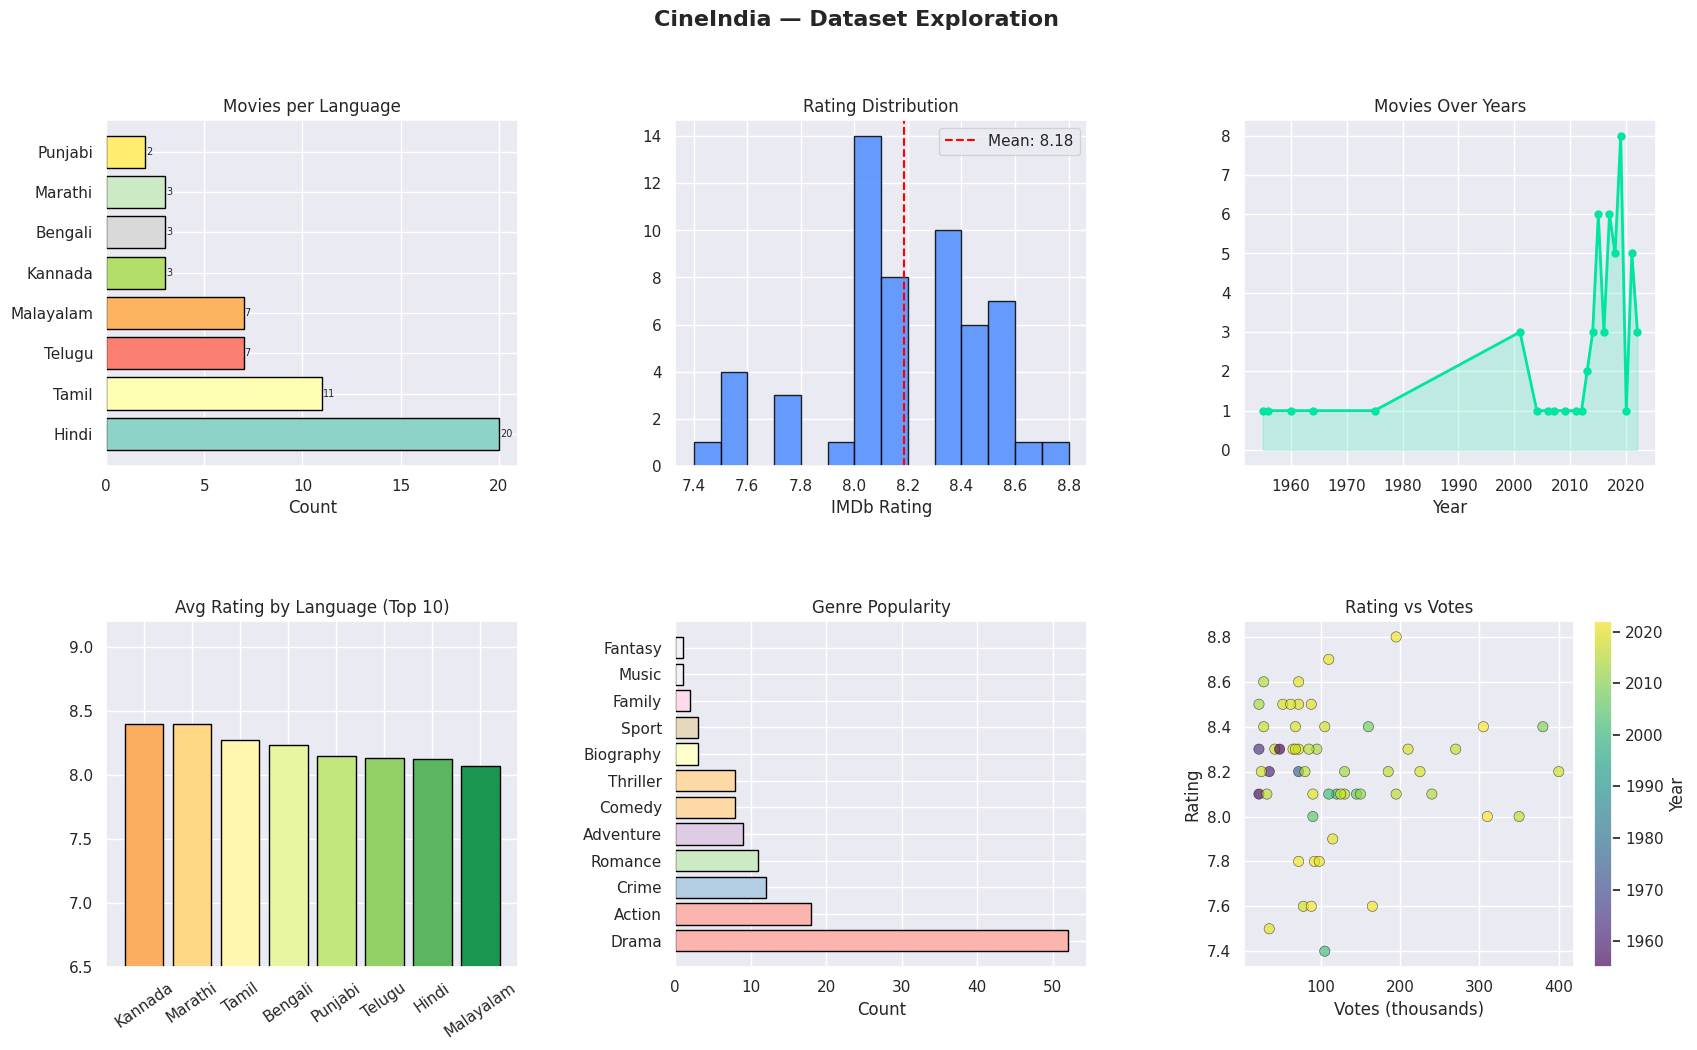

Saved cineindia_eda.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="darkgrid")
print("Plotting exploration charts...")

fig = plt.figure(figsize=(20, 11))
fig.suptitle("CineIndia — Dataset Exploration", fontsize=16, fontweight="bold")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

ax0 = fig.add_subplot(gs[0, 0])
lc = df["language"].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(lc)))
bars = ax0.barh(lc.index, lc.values, color=colors, edgecolor="black")
ax0.set_title("Movies per Language")
ax0.set_xlabel("Count")
for bar in bars:
    ax0.text(bar.get_width()+.05, bar.get_y()+bar.get_height()/2,
             str(int(bar.get_width())), va="center", fontsize=7)

ax1 = fig.add_subplot(gs[0, 1])
ax1.hist(df["rating"], bins=14, color="#4f8cff", edgecolor="black", alpha=0.85)
ax1.axvline(df["rating"].mean(), color="red", linestyle="--",
            label=f"Mean: {df['rating'].mean():.2f}")
ax1.set_title("Rating Distribution")
ax1.set_xlabel("IMDb Rating")
ax1.legend()

ax2 = fig.add_subplot(gs[0, 2])
yearly = df["year"].value_counts().sort_index()
ax2.plot(yearly.index, yearly.values, marker="o", color="#00e5a0", linewidth=2, ms=5)
ax2.fill_between(yearly.index, yearly.values, alpha=0.18, color="#00e5a0")
ax2.set_title("Movies Over Years")
ax2.set_xlabel("Year")

ax3 = fig.add_subplot(gs[1, 0])
avg_r = df.groupby("language")["rating"].mean().sort_values(ascending=False).head(10)
ax3.bar(avg_r.index, avg_r.values,
        color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(avg_r))), edgecolor="black")
ax3.set_title("Avg Rating by Language (Top 10)")
ax3.tick_params(axis="x", rotation=35)
ax3.set_ylim(6.5, 9.2)

ax4 = fig.add_subplot(gs[1, 1])
all_g = [g.strip() for row in df["genre"].str.split(",") for g in row]
gc = pd.Series(all_g).value_counts().head(12)
ax4.barh(gc.index, gc.values,
         color=plt.cm.Pastel1(np.linspace(0, 1, len(gc))), edgecolor="black")
ax4.set_title("Genre Popularity")
ax4.set_xlabel("Count")

ax5 = fig.add_subplot(gs[1, 2])
sc = ax5.scatter(df["votes"]/1000, df["rating"], alpha=0.65,
                  c=df["year"], cmap="viridis", s=55, edgecolors="black", lw=0.4)
ax5.set_title("Rating vs Votes")
ax5.set_xlabel("Votes (thousands)")
ax5.set_ylabel("Rating")
plt.colorbar(sc, ax=ax5, label="Year")

plt.savefig("cineindia_eda.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved cineindia_eda.png")

Build Recommendation System

In [4]:
def build_features(row):
    parts = [
        row["genre"].replace(",", " "),
        row["language"],
        row["director"],
        " ".join(row["cast"].split(",")[:2]),
        row["description"]
    ]
    return " ".join(parts)

df["features"] = df.apply(build_features, axis=1)
tfidf    = TfidfVectorizer(stop_words="english", ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(df["features"])

def get_recommendations(title="", language="All", genre="All",
                        min_rating=5.0, year_from=1950, year_to=2025, n=20):
    mask = (
        (df["rating"]  >= min_rating) &
        (df["year"]    >= year_from)  &
        (df["year"]    <= year_to)
    )
    if language != "All":
        mask &= (df["language"] == language)
    if genre != "All":
        mask &= df["genre"].str.contains(genre, case=False)

    pool = df[mask].copy()

    if title:
        matches = df[df["title"].str.lower() == title.lower()]
        if not matches.empty:
            idx    = matches.index[0]
            sims   = cosine_similarity(tfidf_matrix[idx], tfidf_matrix[pool.index]).flatten()
            pool   = pool.copy()
            pool["_sim"] = sims
            pool   = pool[pool["title"].str.lower() != title.lower()]
            pool   = pool.sort_values("_sim", ascending=False)
        else:
            pool = pool.sort_values("rating", ascending=False)
    else:
        pool = pool.sort_values("rating", ascending=False)

    pool = pool.head(n)
    cols = ["title","language","year","genre","director","cast","rating","description"]
    return pool[cols].to_dict(orient="records")

LANGUAGES = sorted(df["language"].unique().tolist())
GENRES    = sorted(set(g.strip() for gs in df["genre"] for g in gs.split(",")))

print(f"Dataset ready: {len(df)} movies, {len(LANGUAGES)} languages, {len(GENRES)} genres")
print("Run Cell 2 to start the server.")


Dataset ready: 56 movies, 8 languages, 15 genres
Run Cell 2 to start the server.


Launch CineIndia Website

In [5]:
import subprocess, sys, json, threading, time, math, re
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "flask", "flask-cors"], check=True)
subprocess.run("fuser -k 5000/tcp 2>/dev/null; sleep 1", shell=True)

from flask import Flask, request, jsonify, make_response
from flask_cors import CORS
from IPython.display import HTML as IPYHTML, display as ipydisplay

# ── Serialise everything needed by JS ────────────────────────
# Each record has: title, language, year, genre, director, cast, rating, description
MOVIES_JS   = json.dumps(df[["title","language","year","genre",
                               "director","cast","rating","description"]
                             ].to_dict(orient="records"), ensure_ascii=False)
LANGUAGES_JS = json.dumps(LANGUAGES, ensure_ascii=False)
GENRES_JS    = json.dumps(GENRES, ensure_ascii=False)
TOTAL        = len(df)
N_LANGS      = len(LANGUAGES)
AVG_RATING   = round(df["rating"].mean(), 1)
YEAR_SPAN    = f"{df['year'].min()}–{df['year'].max()}"

# ── HTML ──────────────────────────────────────────────────────
# Build as list-join to avoid any triple-quote conflicts
_H = []
_H.append("""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8"/>
<meta name="viewport" content="width=device-width,initial-scale=1"/>
<title>CineIndia</title>
<link href="https://fonts.googleapis.com/css2?family=Playfair+Display:wght@400;700;900&family=DM+Sans:wght@300;400;500;600&family=JetBrains+Mono:wght@400;500&display=swap" rel="stylesheet"/>
<style>
:root{
  --bg:#0a0608;--s1:#120d10;--s2:#1a1218;--card:#201620;
  --bdr:#2d1e28;--bdr2:#3d2a38;
  --gold:#f5c842;--rose:#ff6b8a;--teal:#00d4aa;--violet:#9b59ff;
  --text:#f0e8ec;--muted:#8a7080;--faint:#2d1e28;
  --glow-g:rgba(245,200,66,.3);--glow-r:rgba(255,107,138,.3);
  --r:14px;
}
*,*::before,*::after{box-sizing:border-box;margin:0;padding:0}
html{scroll-behavior:smooth}
body{background:var(--bg);color:var(--text);font-family:'DM Sans',sans-serif;min-height:100vh;overflow-x:hidden}
body::before{content:'';position:fixed;inset:0;z-index:0;pointer-events:none;
  background-image:radial-gradient(ellipse 80% 50% at 50% -10%,rgba(245,200,66,.07),transparent);
}
.wrap{position:relative;z-index:1;max-width:1100px;margin:0 auto;padding:0 18px 80px}

/* filmstrip header */
.strip{width:100%;height:26px;background:repeating-linear-gradient(90deg,var(--s2) 0,var(--s2) 26px,var(--faint) 26px,var(--faint) 34px);display:flex;align-items:center;padding:0 14px;gap:6px;border-bottom:2px solid var(--bdr2)}
.hole{width:14px;height:14px;border-radius:3px;background:var(--bg);border:1px solid var(--bdr2);flex-shrink:0}

/* Header */
header{text-align:center;padding:48px 0 36px}
.crown{font-size:2rem;animation:float 3s ease-in-out infinite;display:block;margin-bottom:12px}
@keyframes float{0%,100%{transform:translateY(0)}50%{transform:translateY(-6px)}}
h1{font-family:'Playfair Display',serif;font-size:clamp(2.2rem,5.5vw,4rem);font-weight:900;letter-spacing:-.02em;
  background:linear-gradient(130deg,var(--gold) 0%,#fff 45%,var(--rose));
  -webkit-background-clip:text;-webkit-text-fill-color:transparent;background-clip:text}
.tagline{margin-top:11px;color:var(--muted);font-size:.88rem;letter-spacing:.04em}
.marquee{margin-top:13px;overflow:hidden;white-space:nowrap}
.mscroll{display:inline-block;animation:mq 30s linear infinite;font-size:.68rem;color:var(--muted);letter-spacing:.1em;text-transform:uppercase}
@keyframes mq{from{transform:translateX(0)}to{transform:translateX(-50%)}}

/* Stats banner */
.sbnr{display:grid;grid-template-columns:repeat(4,1fr);gap:10px;margin-bottom:28px}
.sbn{background:var(--card);border:1px solid var(--bdr);border-radius:var(--r);padding:15px 10px;text-align:center;transition:.2s}
.sbn:hover{border-color:var(--bdr2);transform:translateY(-2px)}
.sbv{font-family:'Playfair Display',serif;font-size:1.35rem;font-weight:700;color:var(--gold)}
.sbk{font-size:.58rem;color:var(--muted);letter-spacing:.12em;text-transform:uppercase;margin-top:4px}

/* Panel */
.panel{background:var(--s1);border:1px solid var(--bdr);border-radius:var(--r);padding:26px;margin-bottom:24px}
.panel-hd{font-family:'Playfair Display',serif;font-size:.95rem;color:var(--gold);margin-bottom:18px}
.g2{display:grid;grid-template-columns:1fr 1fr;gap:13px;margin-bottom:13px}
.g3{display:grid;grid-template-columns:1fr 1fr 1fr;gap:13px;margin-bottom:13px}
.field{display:flex;flex-direction:column;gap:5px}
.field label{font-family:'JetBrains Mono',monospace;font-size:.6rem;letter-spacing:.12em;text-transform:uppercase;color:var(--muted)}
input[type=text],select{width:100%;background:var(--s2);border:1px solid var(--bdr);border-radius:8px;color:var(--text);font-family:'DM Sans',sans-serif;font-size:.87rem;padding:9px 13px;outline:none;transition:.2s;-webkit-appearance:none;appearance:none}
input[type=text]:focus,select:focus{border-color:var(--gold);box-shadow:0 0 0 2px var(--glow-g)}
select option{background:var(--s2);color:var(--text)}
input[type=range]{width:100%;accent-color:var(--gold);cursor:pointer;background:transparent}

/* Buttons */
.brow{display:flex;gap:10px;margin-top:16px}
.btn{padding:12px 24px;font-family:'DM Sans',sans-serif;font-size:.87rem;font-weight:600;
  letter-spacing:.03em;border:none;border-radius:10px;cursor:pointer;transition:.2s;
  display:flex;align-items:center;justify-content:center;gap:7px}
.btn-p{background:linear-gradient(130deg,var(--gold),#e0a010);color:#150a00;flex:1}
.btn-p:hover:not(:disabled){transform:translateY(-2px);box-shadow:0 10px 28px var(--glow-g)}
.btn-p:disabled{opacity:.4;cursor:not-allowed}
.btn-s{background:var(--s2);border:1px solid var(--bdr);color:var(--muted)}
.btn-s:hover{border-color:var(--bdr2);color:var(--text)}
.spin{width:16px;height:16px;border:2px solid rgba(21,10,0,.3);border-top-color:#150a00;
  border-radius:50%;animation:rot .5s linear infinite;display:none}
@keyframes rot{to{transform:rotate(360deg)}}

/* Results */
#results{display:none}
.rhdr{display:flex;justify-content:space-between;align-items:center;margin-bottom:18px}
.rtitle{font-family:'Playfair Display',serif;font-size:1.1rem;color:var(--gold)}
.rcount{font-family:'JetBrains Mono',monospace;font-size:.7rem;color:var(--muted)}

/* Cards */
.grid{display:grid;grid-template-columns:repeat(auto-fill,minmax(290px,1fr));gap:16px}
.mcard{background:var(--card);border:1px solid var(--bdr);border-radius:var(--r);
  padding:18px;cursor:pointer;transition:.25s;position:relative;overflow:hidden}
.mcard::before{content:'';position:absolute;top:0;left:0;right:0;height:3px;
  background:linear-gradient(90deg,var(--gold),var(--rose));
  transform:scaleX(0);transition:.25s;transform-origin:left}
.mcard:hover{border-color:var(--bdr2);transform:translateY(-3px);box-shadow:0 14px 40px rgba(0,0,0,.5)}
.mcard:hover::before{transform:scaleX(1)}
.ctop{display:flex;justify-content:space-between;align-items:flex-start;margin-bottom:9px}
.clng{font-family:'JetBrains Mono',monospace;font-size:.58rem;letter-spacing:.1em;text-transform:uppercase;padding:3px 8px;border-radius:99px;border:1px solid}
.crat{font-family:'JetBrains Mono',monospace;font-size:.82rem;font-weight:600;color:var(--gold)}
.ctitle{font-family:'Playfair Display',serif;font-size:1.05rem;font-weight:700;margin-bottom:3px;line-height:1.2}
.cmeta{font-family:'JetBrains Mono',monospace;font-size:.68rem;color:var(--muted);margin-bottom:8px}
.ctags{display:flex;flex-wrap:wrap;gap:4px;margin-bottom:8px}
.ctag{font-size:.6rem;padding:2px 8px;border-radius:99px;background:var(--faint);color:var(--muted);border:1px solid var(--bdr)}
.cdesc{font-size:.77rem;color:var(--muted);line-height:1.5;display:-webkit-box;-webkit-line-clamp:3;-webkit-box-orient:vertical;overflow:hidden}
.cbar{height:3px;background:var(--faint);border-radius:99px;margin-top:10px;overflow:hidden}
.cbarfill{height:100%;border-radius:99px;background:linear-gradient(90deg,var(--gold),var(--rose))}

/* Modal */
.mbg{position:fixed;inset:0;background:rgba(0,0,0,.88);z-index:1000;
  display:none;align-items:center;justify-content:center;padding:20px}
.mbg.open{display:flex}
.mbox{background:var(--s1);border:1px solid var(--bdr2);border-radius:18px;
  max-width:620px;width:100%;padding:30px;max-height:88vh;overflow-y:auto;position:relative}
.mclose{position:absolute;top:14px;right:14px;background:var(--s2);border:1px solid var(--bdr);
  border-radius:50%;width:30px;height:30px;display:flex;align-items:center;justify-content:center;
  cursor:pointer;font-size:.85rem;color:var(--muted);transition:.2s;line-height:1}
.mclose:hover{border-color:var(--rose);color:var(--rose)}
.mlng{font-family:'JetBrains Mono',monospace;font-size:.62rem;letter-spacing:.12em;text-transform:uppercase;margin-bottom:10px}
.mtitle{font-family:'Playfair Display',serif;font-size:1.7rem;font-weight:900;line-height:1.15;margin-bottom:5px}
.mmeta{font-family:'JetBrains Mono',monospace;font-size:.7rem;color:var(--muted);margin-bottom:14px}
.mrat{display:inline-flex;align-items:center;gap:5px;background:var(--s2);border:1px solid var(--bdr);
  border-radius:8px;padding:7px 13px;margin-bottom:14px}
.mrat big{font-family:'Playfair Display',serif;font-size:1.35rem;font-weight:700;color:var(--gold)}
.msec{margin-bottom:12px}
.msec h4{font-family:'JetBrains Mono',monospace;font-size:.6rem;letter-spacing:.12em;text-transform:uppercase;color:var(--muted);margin-bottom:5px}
.msec p{font-size:.84rem;line-height:1.6}
.mgenres{display:flex;flex-wrap:wrap;gap:5px}
.mgen{font-size:.66rem;padding:3px 11px;border-radius:99px;background:var(--faint);border:1px solid var(--bdr);color:var(--muted)}
.mfind{margin-top:16px;width:100%;padding:12px;font-family:'DM Sans',sans-serif;font-size:.84rem;font-weight:600;
  background:linear-gradient(130deg,var(--gold),#e0a010);color:#150a00;border:none;border-radius:10px;cursor:pointer;transition:.2s}
.mfind:hover{transform:translateY(-1px);box-shadow:0 8px 22px var(--glow-g)}

/* Empty */
.empty{text-align:center;padding:50px 20px;color:var(--muted);grid-column:1/-1}
.empty-ico{font-size:2.8rem;margin-bottom:12px}

/* Language badge colours */
.l-Hindi{color:#ff9166;border-color:rgba(255,145,102,.4);background:rgba(255,145,102,.08)}
.l-Tamil{color:#ff6b8a;border-color:rgba(255,107,138,.4);background:rgba(255,107,138,.08)}
.l-Telugu{color:#00d4aa;border-color:rgba(0,212,170,.4);background:rgba(0,212,170,.08)}
.l-Malayalam{color:#9b59ff;border-color:rgba(155,89,255,.4);background:rgba(155,89,255,.08)}
.l-Kannada{color:#f5c842;border-color:rgba(245,200,66,.4);background:rgba(245,200,66,.08)}
.l-Bengali{color:#4f8cff;border-color:rgba(79,140,255,.4);background:rgba(79,140,255,.08)}
.l-Marathi{color:#ff6b6b;border-color:rgba(255,107,107,.4);background:rgba(255,107,107,.08)}
.l-Punjabi{color:#ffd166;border-color:rgba(255,209,102,.4);background:rgba(255,209,102,.08)}
.l-other{color:#8a7080;border-color:rgba(138,112,128,.35);background:rgba(138,112,128,.06)}

.foot{text-align:center;font-size:.63rem;color:var(--faint);margin-top:36px;letter-spacing:.04em;line-height:1.9}
.foot strong{color:var(--muted)}
::-webkit-scrollbar{width:5px}
::-webkit-scrollbar-track{background:var(--bg)}
::-webkit-scrollbar-thumb{background:var(--bdr2);border-radius:99px}
@media(max-width:580px){.sbnr,.g2,.g3{grid-template-columns:repeat(2,1fr)}.grid{grid-template-columns:1fr}}
</style>
</head>
<body>""")

# filmstrip
_H.append("<div class='strip'>" + "<div class='hole'></div>"*28 + "</div>")

_H.append("""
<div class='wrap'>
<header>
  <span class='crown'>🎬</span>
  <h1>CineIndia</h1>
  <p class='tagline'>Discover the best of Indian cinema across every language</p>
  <div class='marquee'>
    <span class='mscroll'>
      HINDI &middot; TAMIL &middot; TELUGU &middot; MALAYALAM &middot; KANNADA &middot; BENGALI &middot; MARATHI &middot; PUNJABI &middot; GUJARATI &middot; ODIA &middot; ASSAMESE &middot; BHOJPURI &middot; MAITHILI &middot; KONKANI &middot; MANIPURI &middot; SANTALI &middot;&nbsp;
      HINDI &middot; TAMIL &middot; TELUGU &middot; MALAYALAM &middot; KANNADA &middot; BENGALI &middot; MARATHI &middot; PUNJABI &middot; GUJARATI &middot; ODIA &middot; ASSAMESE &middot; BHOJPURI &middot; MAITHILI &middot; KONKANI &middot; MANIPURI &middot; SANTALI &middot;
    </span>
  </div>
</header>""")

_H.append(f"""
<div class='sbnr'>
  <div class='sbn'><div class='sbv'>{TOTAL}</div><div class='sbk'>Movies</div></div>
  <div class='sbn'><div class='sbv'>{N_LANGS}</div><div class='sbk'>Languages</div></div>
  <div class='sbn'><div class='sbv'>{AVG_RATING}</div><div class='sbk'>Avg Rating</div></div>
  <div class='sbn'><div class='sbv'>{YEAR_SPAN}</div><div class='sbk'>Years</div></div>
</div>""")

_H.append("""
<div class='panel'>
  <div class='panel-hd'>&#128269; Find Movies</div>
  <div class='g2'>
    <div class='field'>
      <label>Movie (for similar recommendations)</label>
      <input type='text' id='fTitle' placeholder='e.g. Drishyam, 3 Idiots, RRR...' list='titleDL' autocomplete='off'/>
      <datalist id='titleDL'></datalist>
    </div>
    <div class='field'>
      <label>Language</label>
      <select id='fLang'><option value='All'>All Languages</option></select>
    </div>
  </div>
  <div class='g3'>
    <div class='field'>
      <label>Genre</label>
      <select id='fGenre'><option value='All'>All Genres</option></select>
    </div>
    <div class='field'>
      <label>Min Rating &mdash; <span id='rLbl' style='color:var(--gold)'>6.0</span></label>
      <input type='range' id='fRating' min='5' max='9.5' step='0.1' value='6.0'
             oninput="document.getElementById('rLbl').textContent=parseFloat(this.value).toFixed(1)"/>
    </div>
    <div class='field'>
      <label>Sort By</label>
      <select id='fSort'>
        <option value='rating'>Highest Rated</option>
        <option value='year'>Newest First</option>
        <option value='votes'>Most Popular</option>
      </select>
    </div>
  </div>
  <div class='g2'>
    <div class='field'>
      <label>Year From</label>
      <input type='text' id='fYF' value='1950' placeholder='1950'/>
    </div>
    <div class='field'>
      <label>Year To</label>
      <input type='text' id='fYT' value='2025' placeholder='2025'/>
    </div>
  </div>
  <div class='brow'>
    <button class='btn btn-p' id='recBtn' onclick='getRec()'>
      <span id='recLbl'>&#10024; Get Recommendations</span>
      <div class='spin' id='recSpin'></div>
    </button>
    <button class='btn btn-s' onclick='resetAll()'>&#8634; Reset</button>
  </div>
</div>

<div id='results'>
  <div class='rhdr'>
    <div class='rtitle' id='rTitle'>Recommendations</div>
    <div class='rcount' id='rCount'></div>
  </div>
  <div class='grid' id='grid'></div>
</div>

<!-- Modal -->
<div class='mbg' id='mbg'>
  <div class='mbox'>
    <div class='mclose' id='mcloseBtn'>&#10005;</div>
    <div class='mlng' id='mLng'></div>
    <div class='mtitle' id='mTitle'></div>
    <div class='mmeta'  id='mMeta'></div>
    <div class='mrat'><span>&#11088;</span><big id='mRat'></big><span style='font-size:.72rem;color:var(--muted);margin-left:3px'>/ 10</span></div>
    <div class='msec'><h4>Story</h4><p id='mDesc'></p></div>
    <div class='msec'><h4>Director</h4><p id='mDir'></p></div>
    <div class='msec'><h4>Cast</h4><p id='mCast'></p></div>
    <div class='msec'><h4>Genres</h4><div class='mgenres' id='mGenres'></div></div>
    <button class='mfind' id='mFindBtn'>&#127909; Find Similar Movies</button>
  </div>
</div>""")

_H.append(f"""
<div class='foot'>
  CineIndia &nbsp;&middot;&nbsp; <strong>{TOTAL} movies</strong> across <strong>{N_LANGS} Indian languages</strong><br/>
  scikit-learn &nbsp;&bull;&nbsp; TF-IDF Cosine Similarity &nbsp;&bull;&nbsp; Flask
</div>
</div>""")

_H.append("""
<script>
// ── Data injected from Python ──────────────────────────────
const MOVIES    = MOVIES_PLACEHOLDER;
const LANGUAGES = LANGS_PLACEHOLDER;
const GENRES    = GENRES_PLACEHOLDER;

// ── Populate dropdowns & datalist ──────────────────────────
(function init(){
  const langSel = document.getElementById('fLang');
  LANGUAGES.forEach(function(l){
    var o = document.createElement('option'); o.value = l; o.textContent = l;
    langSel.appendChild(o);
  });
  const genSel = document.getElementById('fGenre');
  GENRES.forEach(function(g){
    var o = document.createElement('option'); o.value = g; o.textContent = g;
    genSel.appendChild(o);
  });
  const dl = document.getElementById('titleDL');
  MOVIES.forEach(function(m){
    var o = document.createElement('option'); o.value = m.title;
    dl.appendChild(o);
  });
})();

// ── Language badge class ────────────────────────────────────
function lClass(lang){
  var map = {Hindi:'l-Hindi',Tamil:'l-Tamil',Telugu:'l-Telugu',
             Malayalam:'l-Malayalam',Kannada:'l-Kannada',
             Bengali:'l-Bengali',Marathi:'l-Marathi',Punjabi:'l-Punjabi'};
  return map[lang] || 'l-other';
}

// ── Render movie cards ──────────────────────────────────────
function renderCards(movies, queryTitle){
  var grid   = document.getElementById('grid');
  var resDiv = document.getElementById('results');
  var rTitle = document.getElementById('rTitle');
  var rCount = document.getElementById('rCount');

  resDiv.style.display = 'block';
  rCount.textContent   = movies.length + ' movies';

  if(queryTitle){
    rTitle.textContent = 'Similar to "' + queryTitle + '"';
  } else {
    rTitle.textContent = 'Recommended for You';
  }

  if(!movies.length){
    grid.innerHTML = '<div class="empty"><div class="empty-ico">&#127909;</div><p>No movies found. Try relaxing your filters.</p></div>';
    return;
  }

  grid.innerHTML = movies.map(function(m, i){
    var lc     = lClass(m.language);
    var tags   = m.genre.split(',').map(function(g){
      return '<span class="ctag">' + g.trim() + '</span>';
    }).join('');
    var barPct = Math.round(((m.rating - 5) / 4.5) * 100);
    // Store index so modal can look it up
    return '<div class="mcard" data-idx="' + i + '" onclick="openModal(' + i + ')">'
      + '<div class="ctop">'
      + '<span class="clng ' + lc + '">' + m.language + '</span>'
      + '<span class="crat">&#11088; ' + m.rating + '</span>'
      + '</div>'
      + '<div class="ctitle">' + esc(m.title) + '</div>'
      + '<div class="cmeta">' + m.year + ' &middot; ' + esc(m.director) + '</div>'
      + '<div class="ctags">' + tags + '</div>'
      + '<div class="cdesc">' + esc(m.description) + '</div>'
      + '<div class="cbar"><div class="cbarfill" style="width:' + barPct + '%"></div></div>'
      + '</div>';
  }).join('');

  resDiv.scrollIntoView({behavior:'smooth', block:'start'});
}

// ── Escape HTML ─────────────────────────────────────────────
function esc(s){ return String(s).replace(/&/g,'&amp;').replace(/</g,'&lt;').replace(/>/g,'&gt;').replace(/"/g,'&quot;'); }

// ── Current displayed movies (for modal) ───────────────────
var _movies = [];
var _curIdx = 0;

// ── Get recommendations ─────────────────────────────────────
async function getRec(){
  var btn  = document.getElementById('recBtn');
  var spin = document.getElementById('recSpin');
  var lbl  = document.getElementById('recLbl');
  btn.disabled = true; lbl.style.display = 'none'; spin.style.display = 'block';

  try{
    var payload = {
      title     : document.getElementById('fTitle').value.trim(),
      language  : document.getElementById('fLang').value,
      genre     : document.getElementById('fGenre').value,
      min_rating: parseFloat(document.getElementById('fRating').value),
      year_from : parseInt(document.getElementById('fYF').value)  || 1950,
      year_to   : parseInt(document.getElementById('fYT').value)  || 2025,
      sort_by   : document.getElementById('fSort').value,
      n         : 24
    };
    var res  = await fetch('/recommend', {
      method : 'POST',
      headers: {'Content-Type':'application/json'},
      body   : JSON.stringify(payload)
    });
    if(!res.ok) throw new Error('Server error ' + res.status);
    var data = await res.json();
    _movies  = data.movies;
    renderCards(_movies, data.query_title);
  } catch(e){
    alert('Request failed: ' + e.message);
  } finally{
    btn.disabled = false; lbl.style.display = 'block'; spin.style.display = 'none';
  }
}

// ── Modal ────────────────────────────────────────────────────
function openModal(idx){
  _curIdx = idx;
  var m  = _movies[idx];
  if(!m) return;
  var lc = lClass(m.language);

  document.getElementById('mLng').innerHTML =
    '<span class="clng ' + lc + '">' + esc(m.language) + '</span>';
  document.getElementById('mTitle').textContent = m.title;
  document.getElementById('mMeta').textContent  = m.year + ' \u00b7 Directed by ' + m.director;
  document.getElementById('mRat').textContent   = m.rating;
  document.getElementById('mDesc').textContent  = m.description;
  document.getElementById('mDir').textContent   = m.director;
  document.getElementById('mCast').textContent  = m.cast;
  document.getElementById('mGenres').innerHTML  =
    m.genre.split(',').map(function(g){
      return '<span class="mgen">' + esc(g.trim()) + '</span>';
    }).join('');

  document.getElementById('mbg').classList.add('open');
}

function closeModal(){
  document.getElementById('mbg').classList.remove('open');
}

// Close on background click
document.getElementById('mbg').addEventListener('click', function(e){
  if(e.target === this) closeModal();
});
document.getElementById('mcloseBtn').addEventListener('click', closeModal);

// Find similar button
document.getElementById('mFindBtn').addEventListener('click', function(){
  var m = _movies[_curIdx];
  if(!m) return;
  document.getElementById('fTitle').value = m.title;
  closeModal();
  getRec();
});

// ── Reset ────────────────────────────────────────────────────
function resetAll(){
  document.getElementById('fTitle').value  = '';
  document.getElementById('fLang').value   = 'All';
  document.getElementById('fGenre').value  = 'All';
  document.getElementById('fRating').value = 6.0;
  document.getElementById('rLbl').textContent = '6.0';
  document.getElementById('fYF').value     = '1950';
  document.getElementById('fYT').value     = '2025';
  document.getElementById('fSort').value   = 'rating';
  document.getElementById('results').style.display = 'none';
}

// ── ESC closes modal ─────────────────────────────────────────
document.addEventListener('keydown', function(e){
  if(e.key === 'Escape') closeModal();
});

// ── Load top picks on page open ──────────────────────────────
window.addEventListener('load', function(){
  fetch('/recommend',{
    method :'POST',
    headers:{'Content-Type':'application/json'},
    body   :JSON.stringify({
      title:'', language:'All', genre:'All',
      min_rating:8.0, year_from:1950, year_to:2025,
      sort_by:'rating', n:12
    })
  })
  .then(function(r){ return r.json(); })
  .then(function(d){ _movies = d.movies; renderCards(_movies, null); })
  .catch(function(){});
});
</script>
</body></html>""")

HTML = (
    "\n".join(_H)
    .replace("MOVIES_PLACEHOLDER",    MOVIES_JS)
    .replace("LANGS_PLACEHOLDER",     LANGUAGES_JS)
    .replace("GENRES_PLACEHOLDER",    GENRES_JS)
)

# ── Flask ─────────────────────────────────────────────────────
app = Flask(__name__)
CORS(app)

@app.route("/")
def home():
    return make_response(HTML, 200, {"Content-Type":"text/html; charset=utf-8"})

@app.route("/recommend", methods=["POST"])
def recommend_route():
    body     = request.get_json(force=True)
    title    = body.get("title",     "").strip()
    language = body.get("language",  "All")
    genre    = body.get("genre",     "All")
    min_r    = float(body.get("min_rating", 5.0))
    year_f   = int(body.get("year_from",  1950))
    year_t   = int(body.get("year_to",    2025))
    sort_by  = body.get("sort_by",   "rating")
    n        = int(body.get("n",      20))

    recs = get_recommendations(
        title=title, language=language, genre=genre,
        min_rating=min_r, year_from=year_f, year_to=year_t, n=n
    )

    # Client-side sort is already done in JS, but honour sort_by on Python side too
    if sort_by == "year":
        recs = sorted(recs, key=lambda x: x["year"], reverse=True)
    elif sort_by == "votes":
        vote_map = df.set_index("title")["votes"].to_dict()
        recs = sorted(recs, key=lambda x: vote_map.get(x["title"],0), reverse=True)
    # "rating" is default from get_recommendations

    return jsonify({
        "movies"      : recs,
        "query_title" : title if title else None,
        "total"       : len(recs)
    })

# ── Start server ──────────────────────────────────────────────
PORT = 5000
threading.Thread(
    target=lambda: app.run(
        host="0.0.0.0", port=PORT,
        use_reloader=False, debug=False, threaded=True
    ),
    daemon=True
).start()
time.sleep(2)
print("Flask server started on port", PORT)

# ── Print URL clearly ─────────────────────────────────────────
from google.colab.output import eval_js
url = eval_js(f"google.colab.kernel.proxyPort({PORT})")

print("\n" + "="*60)
print("  CineIndia is LIVE!")
print("  " + str(url))
print("="*60)
print("  Copy-paste the link above into a new browser tab")
print("  Stop / interrupt this cell to shut down")
print("="*60 + "\n")

from IPython.display import HTML as IPYHTML, display as ipydisplay
ipydisplay(IPYHTML(f"""
<div style="margin:14px 0;padding:20px 24px;
  background:linear-gradient(135deg,#201620,#120d10);
  border:2px solid #f5c842;border-radius:14px;
  font-family:Georgia,serif;max-width:600px">
  <div style="color:#8a7080;font-size:13px;margin-bottom:8px">
    🎬 CineIndia Movie Recommender is running!
  </div>
  <a href="{url}" target="_blank"
     style="color:#f5c842;font-size:17px;font-weight:bold;
            text-decoration:none;word-break:break-all">
    {url}
  </a>
  <div style="color:#8a7080;font-size:11px;margin-top:8px;line-height:1.7">
    {TOTAL} movies &nbsp;·&nbsp; {N_LANGS} Indian languages &nbsp;·&nbsp;
    Content-based ML recommendations<br/>
    Click the gold link above to open the website
  </div>
</div>
"""))

try:
    while True:
        time.sleep(30)
except KeyboardInterrupt:
    print("Server stopped.")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


Flask server started on port 5000

  CineIndia is LIVE!
  https://5000-m-s-kkb-use1d2-3eqdqi1trw08r-d.us-east1-2.prod.colab.dev
  Copy-paste the link above into a new browser tab
  Stop / interrupt this cell to shut down



Server stopped.
